# 在 AMD Instinct™ GPU 上动手实践 verl 强化学习训练

 ## 为什么要做强化学习训练？

预训练让模型"会说话"，SFT 让模型"会按格式说话"，但要让模型在**可验证的任务上稳定做对事**，往往还需要强化学习这一步。

RL 和前两个阶段的根本区别在于训练信号：
- **预训练 / SFT**：告诉模型"下一个 token 应该是什么"。
- **RL**：告诉模型"你这次完整输出值多少分"，让模型在反复采样中自己学会朝高分方向走。

也正因为信号粒度不同，RL 特别适合那些"过程可以多样、但结果必须正确"的任务 — 数学题、代码、工具调用、Agent 决策都是典型例子。

---

### RL 通常能优化哪些行为？

#### 1. 推理过程更可靠

对于需要多步推理的任务，RL 会强化"能拿到正确结果的推理路径"，并抑制跳步、口算、半途放弃这类容易出错的行为。

> **问题示例：** 一家面包店周一烤了 240 个面包，周二比周一多烤 25%，周三又比周二少了三分之一。三天总共烤了多少个面包？
>
> RL 训练后的模型更倾向于：明确分出 Mon / Tue / Wed 三步、写出每一步的算式、最后给出总和 — 而不是一句"大概 700 多吧"。

#### 2. 输出格式严格合规

只要奖励函数对格式敏感（比如"必须以 `#### 答案` 结尾才给分"），模型很快就会学会按规矩交卷。这一点对下游解析、自动评测、流水线对接极其重要。

#### 3. 工具与决策更准

在 Agent 场景中，RL 可以训练模型在多个工具中选对那个、并传入正确参数：

> 用户问："今天北京天气怎么样？"
> 可用工具：`search_web(query)`、`get_weather(city)`、`calculator(expr)`
>
> 经过 RL 训练的模型更倾向于直接调用 `get_weather("北京")`，而不是绕道 `search_web`；调用失败时也更倾向于换工具或修参数再试，而不是硬编一个答案。

#### 4. 可验证任务上的准确率

凡是奖励能被自动判定的任务 — 数学题、代码能否运行、单元测试是否通过、API 是否调用成功 — RL 都能持续把准确率往上推。这是和 RLHF 的差别：不需要人类打分，只要有一个能跑的 reward function。

---

### 核心机制一句话

> RL 不告诉模型"应该输出什么"，只告诉它"这次输出值多少分"。模型采样多条候选、对比奖励高低，把得分高的方向往参数里"刻"进去 — 这就是 GRPO 正在做的事。

接下来本 workshop 会用 **GRPO + LoRA** 在 GSM8K 数学题上跑一次完整的 RL 训练流程：

- **Step 1–6**：准备环境、数据集、基础模型，并理解关键训练配置。
- **Step 7**：启动训练，期间每隔几步会在验证集上跑一次 evaluation，输出 `val-core/openai/gsm8k/acc/mean@1` — 你会看到这个指标随训练步数稳步上升，这就是上面"可验证任务上的准确率"在被 RL 一步步往上推的过程。
- **Step 8**：训练结束后加载保存的 checkpoint，让模型解一道未见过的 GSM8K 题，观察它的推理过程和输出格式 — 是否符合上面提到的"分步推理 + 严格 `####` 格式"的特征。

### 这套训练用到的组件

下面这张表概括了我们会用到的模型、数据、算法和运行栈 — 后面所有 step 都是围绕这一套配置展开的，遇到陌生字段可以随时回到这里对照。

| Layer | Setting |
|---|---|
| Model | `Qwen/Qwen3-4B` |
| Dataset | GSM8K |
| RL algorithm | `algorithm.adv_estimator=grpo` |
| Fine-tuning | LoRA — `actor_rollout_ref.model.lora_rank=32`, `actor_rollout_ref.model.lora_alpha=64` |
| Rollout backend | `actor_rollout_ref.rollout.name=vllm` |
| Number of samples | `actor_rollout_ref.rollout.n=5` |
| Tensor parallel size | `actor_rollout_ref.rollout.tensor_model_parallel_size=1` |
| Framework version | verl v0.8.0dev |
| Rollout runtime | vLLM 0.18.0 with ROCm 7.0 |
| Hardware | AMD Instinct (gfx942), single GPU |

 ### verl 和 vLLM 在训练循环中各自做什么

上表里出现的 `verl` 和 `vLLM` 在每个训练步里有明确的分工：**verl 控制整个 RL 训练循环，vLLM 专门负责 rollout 时的高效生成**。两者通过 LoRA 权重同步衔接 — 每次参数更新后，verl 会把新的 LoRA 权重推给 vLLM，下一步
rollout 立即用上最新模型，不需要重启。

```text
Prompt batch
  ↓
vLLM rollout engine generates G responses per prompt (group sampling)
  ↓
Reward function scores each response
  ↓
GRPO computes group-relative advantages (per-prompt baseline)
  ↓
Training engine recomputes log-probs; PPO-clipped loss + KL-to-reference
  ↓
Optimizer updates LoRA adapters on the actor
  ↓
verl syncs updated LoRA weights into the vLLM engine
  ↓
Next training step

---
理解了上面这套"概念 → 配置 → 组件分工"的全貌，下面就可以正式动手了 — 先从最基础的环境检查开始，确认 GPU、verl、vLLM 都已经就绪。

 ## Step 1: 检查 AMD GPU

  在启动 verl 之前，先确认容器内可以正常识别 AMD GPU。你应该能看到一个 GPU 设备，并满足以下条件：

  - **GPU-Name** 中包含 `AMD Instinct` 
  - 头部信息中显示 **ROCm version** `7.0` 
  - **Mem-Usage** 基本为空闲状态，(例如每张 GPU 空闲时大约为 `~300 MB / 196592 MB`)

In [31]:
!amd-smi

+------------------------------------------------------------------------------+
| AMD-SMI 26.0.2+39589fda      amdgpu version: 6.14.14  ROCm version: 7.0.2    |
| Platform: Linux Baremetal                                                    |
|-------------------------------------+----------------------------------------|
| BDF                        GPU-Name | Mem-Uti   Temp   UEC       Power-Usage |
| GPU  HIP-ID  OAM-ID  Partition-Mode | GFX-Uti    Fan               Mem-Usage |
|=====================================+========================================|
| 0000:0c:00.0 ...Instinct MI300X OAM | 0 %      49 °C   0           185/750 W |
|   0       0       2        SPX/NPS1 | 0 %        N/A         18176/196592 MB |
|-------------------------------------+----------------------------------------|
| 0000:22:00.0 ...Instinct MI300X OAM | 0 %      47 °C   0           159/750 W |
|   1       1       1        SPX/NPS1 | 0 %        N/A          9754/196592 MB |
|---------------------------

## Step 2: 验证 verl 是否安装成功

本 workshop 运行在预构建的 rocm/verl 容器中，该容器已经将 verl 以可编辑安装的方式安装在 /workspace/verl 路径下。

下面的代码单元会检查 verl 是否已正确安装，并打印当前版本。

In [33]:
import importlib, sys

try:
  import verl
  print("verl version :", verl.__version__)
  print("verl module  :", verl.__file__)
except ImportError:
  sys.exit(
      "verl is not installed. This notebook expects the rocm/verl image "
  )

verl version : 0.8.0.dev
verl module  : /workspace/verl/verl/__init__.py


 ## Step 3: 检查 vLLM 和 ROCm 运行环境

下面的代码单元会确认：

- vLLM 可以正常导入
- PyTorch 是 ROCm 构建版本，并且可以检测到 HIP 运行时
- 至少有一张 AMD GPU 可以被 PyTorch 识别

In [34]:
import sys

import vllm
import torch

hip_version = getattr(torch.version, "hip", None)
device_count = torch.cuda.device_count() if torch.cuda.is_available() else 0

print("vLLM version    :", vllm.__version__)
print("HIP runtime     :", hip_version or "NOT a ROCm build")
print("GPUs visible    :", device_count)

assert hip_version, "PyTorch is not built with ROCm/HIP — install the ROCm wheel."
assert device_count > 0, "No AMD GPUs visible — check --device=/dev/dri --device=/dev/kfd."

print("OK: vLLM + ROCm runtime ready.")

vLLM version    : 0.18.1rc1.dev150+g71161e8b6
HIP runtime     : 7.0.51831-7c9236b16
GPUs visible    : 8
OK: vLLM + ROCm runtime ready.


  ## Step 4: 准备 GSM8K 数据集

我们使用 GSM8K，也就是小学数学应用题数据集。它可以提供确定性的奖励：每个样本都会以 #### <number> 标记结尾，因此 GRPO 的奖励函数只需要提取模型输出的最终数字，并与标准答案进行字符串比较即可。

verl 提供了一个预处理脚本： `examples/data_preprocess/gsm8k.py`，该脚本会从 Hugging Face 下载 GSM8K 数据集，并生成训练器需要使用的： `train.parquet` / `test.parquet`.

下面这个脚本会检查 /root/data/gsm8k 下是否已经存在 train.parquet 和 test.parquet；如果不存在，就运行 verl 提供的 GSM8K 预处理脚本下载并生成数据文件，最后列出生成后的文件。

In [35]:
%%bash
set -e

VERL_DIR=/workspace/verl
DATA_DIR=/root/data/gsm8k

if [ -f "${DATA_DIR}/train.parquet" ] && [ -f "${DATA_DIR}/test.parquet" ]; then
echo "GSM8K already prepared at ${DATA_DIR}, skipping."
else
mkdir -p "${DATA_DIR}"
python3 "${VERL_DIR}/examples/data_preprocess/gsm8k.py" --local_dir "${DATA_DIR}"
fi

echo "Files in ${DATA_DIR}:"
ls -lh "${DATA_DIR}"

GSM8K already prepared at /root/data/gsm8k, skipping.
Files in /root/data/gsm8k:
total 7.4M
-rw-r--r-- 1 root root 1.2M May 11 13:24 test.parquet
-rw-r--r-- 1 root root 6.3M May 11 13:24 train.parquet


## Step 5: 准备 Qwen3-4B 基础模型

在这一步中，我们会为后续训练流程准备 Qwen3-4B 基础模型。

代码会先检查模型是否已经存在于本地 Hugging Face 缓存中。如果本地缓存中没有找到模型文件，则会通过 `from_pretrained` 自动下载模型；如果模型已经缓存，则会直接复用本地文件，跳过下载过程。

这一步主要用于确保后续训练所需的模型文件都已经准备好，包括：

- tokenizer 文件
- 模型配置文件
- 模型权重分片文件

In [36]:
from pathlib import Path

MODEL_PATH  = "Qwen/Qwen3-4B"
# HF stores snapshots under hub/models--<org>--<name>/.
hf_cache = Path("/root/.cache/huggingface/hub")
model_dir = hf_cache / f"models--{MODEL_PATH.replace('/', '--')}"

if not model_dir.exists() or not any(model_dir.rglob("*.safetensors")):
  print(f"{MODEL_PATH} not found in HF cache — downloading via transformers.")

  import transformers
  # from_pretrained downloads config, tokenizer, and weight shards into the HF cache,
  # then materializes the model object. We keep it on CPU and discard immediately —
  # the goal here is only to populate the cache for the trainer in Step 8.
  tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_PATH)
  model     = transformers.AutoModelForCausalLM.from_pretrained(
      MODEL_PATH,
      torch_dtype="auto",
      device_map="cpu",
  )
  del model, tokenizer
else:
  print(f"{MODEL_PATH} already cached at {model_dir}, skipping download.")

# Show what's in the snapshot so the reader sees what an LLM repo actually contains.
snapshot_root = next((model_dir / "snapshots").iterdir(), None)
if snapshot_root is not None:
  print(f"\nFiles in snapshot ({snapshot_root.name}):")
  for p in sorted(snapshot_root.iterdir()):
      size_mb = p.stat().st_size / (1024 * 1024) if p.is_file() else 0
      print(f"  {p.name:<40} {size_mb:>8.1f} MB" if p.is_file() else f"  {p.name}/")

Qwen/Qwen3-4B already cached at /root/.cache/huggingface/hub/models--Qwen--Qwen3-4B, skipping download.

Files in snapshot (1cfa9a7208912126459214e8b04321603b3df60c):
  config.json                                   0.0 MB
  generation_config.json                        0.0 MB
  merges.txt                                    1.6 MB
  model-00001-of-00003.safetensors           3774.5 MB
  model-00002-of-00003.safetensors           3802.7 MB
  model-00003-of-00003.safetensors             95.0 MB
  model.safetensors.index.json                  0.0 MB
  tokenizer.json                               10.9 MB
  tokenizer_config.json                         0.0 MB
  vocab.json                                    2.6 MB


## Step 6: 理解核心训练配置

### Algorithm — GRPO

| Config | Value | Meaning |
|---|---|---|
| `algorithm.adv_estimator` | `grpo` | Group-relative advantages instead of GAE — this is what makes the run GRPO, not vanilla PPO |
| `algorithm.use_kl_in_reward` | `False` | KL is applied as a **loss term**, not folded into the reward |
| `actor_rollout_ref.actor.use_kl_loss` | `True` | Add a KL penalty against the frozen reference model (anchors the policy, prevents collapse) |
| `actor_rollout_ref.actor.kl_loss_coef` | `0.001` | Strength of that KL penalty |
| `actor_rollout_ref.actor.kl_loss_type` | `low_var_kl` | Low-variance KL estimator (k3) — more stable gradients than the naive log-ratio form |
| `actor_rollout_ref.actor.entropy_coeff` | `0` | No entropy bonus; GRPO's group baseline already provides exploration pressure |

### Model and LoRA

| Config | Value | Meaning |
|---|---|---|
| `actor_rollout_ref.model.path` | `Qwen/Qwen3-4B` | Base model — pulled from the HF cache populated in Step 5 |
| `actor_rollout_ref.model.lora_rank` | `32` | Rank of the LoRA matrices A (d × 64) and B (64 × d). Higher = more capacity, more trainable params |
| `actor_rollout_ref.model.lora_alpha` | `64` | LoRA scaling. Effective scale = `alpha / rank = 2` |
| `actor_rollout_ref.model.use_remove_padding` | `True` | Pack variable-length sequences without pad tokens — fewer wasted FLOPs |
| `actor_rollout_ref.model.enable_gradient_checkpointing` | `True` | Trade compute for memory by recomputing activations in the backward pass |

### Rollout (vLLM)

| Config | Value | Meaning |
|---|---|---|
| `actor_rollout_ref.rollout.name` | `vllm` | Use vLLM as the rollout engine |
| `actor_rollout_ref.rollout.n` | `5` | Sample 5 responses per prompt — this is the GRPO group size |
| `actor_rollout_ref.rollout.tensor_model_parallel_size` | `1` | vLLM does not shard the model across GPUs (single-GPU run) |
| `actor_rollout_ref.rollout.gpu_memory_utilization` | `0.6` | Fraction of GPU memory vLLM may use for its KV cache. The remainder is reserved for the trainer's actor + optimizer state + activations — essential when vLLM and training share one GPU |
| `actor_rollout_ref.rollout.load_format` | `safetensors` | Load weights from safetensors shards directly |
| `actor_rollout_ref.rollout.layered_summon` | `True` | Pull the merged actor weights into vLLM layer-by-layer to keep peak memory low when syncing the policy after each update |
| `actor_rollout_ref.rollout.log_prob_use_dynamic_bsz` | `True` | Pack rollout log-prob recomputation into token-budget batches (see below) |
| `actor_rollout_ref.rollout.log_prob_max_token_len_per_gpu` | `9216` | Token budget per GPU when recomputing rollout log-probs |

### Actor / training engine (FSDP)

| Config | Value | Meaning |
|---|---|---|
| `actor_rollout_ref.actor.optim.lr` | `1e-5` | Learning rate for the LoRA adapter optimizer |
| `actor_rollout_ref.actor.ppo_mini_batch_size` | `16` | Prompts per PPO mini-batch update |
| `actor_rollout_ref.actor.use_dynamic_bsz` | `True` | Bin samples by total token count instead of fixed batch size — keeps GPU work uniform when sequence lengths vary |
| `actor_rollout_ref.actor.ppo_max_token_len_per_gpu` | `9216` | Token budget per GPU per micro-batch (the cap that `use_dynamic_bsz` packs into) |
| `actor_rollout_ref.actor.fsdp_config.param_offload` | `False` | Keep actor weights on GPU (faster; we have headroom on AMD Instinct GPU) |
| `actor_rollout_ref.actor.fsdp_config.optimizer_offload` | `False` | Keep optimizer state on GPU as well |

### Reference policy

| Config | Value | Meaning |
|---|---|---|
| `actor_rollout_ref.ref.fsdp_config.param_offload` | `True` | Offload the frozen reference model to CPU — it's only used for KL, so the latency hit is worth the freed VRAM |
| `actor_rollout_ref.ref.log_prob_use_dynamic_bsz` | `True` | Same dynamic batching for the reference forward pass |
| `actor_rollout_ref.ref.log_prob_max_token_len_per_gpu` | `9216` | Token budget per GPU for the reference log-prob pass |

### Data

| Config | Value | Meaning |
|---|---|---|
| `data.train_files` | `$HOME/data/gsm8k/train.parquet` | Training prompts — produced in Step 4 (`/root/data/gsm8k/train.parquet`) |
| `data.val_files` | `$HOME/data/gsm8k/test.parquet` | Eval prompts |
| `data.train_batch_size` | `16` | Prompts sampled per RL step; each is expanded into `n=5` rollouts → 80 sequences/step |
| `data.max_prompt_length` | `1024` | Max prompt tokens |
| `data.max_response_length` | `1024` | Max generated tokens per rollout |
| `data.filter_overlong_prompts` | `True` | Drop prompts that exceed `max_prompt_length` rather than truncate |
| `data.truncation` | `error` | Hard-fail on overlong sequences (catches data-prep bugs early) |

### Trainer schedule

| Config | Value | Meaning |
|---|---|---|
| `trainer.n_gpus_per_node` | `1` | Single-GPU run |
| `trainer.nnodes` | `1` | Single node |
| `trainer.balance_batch` | `True` | Balance token counts across DP ranks (no-op on a single GPU, kept on for portability) |
| `trainer.val_before_train` | `False` | Skip the pre-training eval — saves ~1 minute |
| `trainer.total_epochs` | `15` | Upper bound on passes over the GSM8K train set; in this workshop the run stops earlier because of `total_training_steps` |
| `trainer.total_training_steps` | `40` | Hard cap on GRPO steps — this is what actually ends the run (40 × ~40s ≈ 27 min on one MI300X) |
| `trainer.logger` | `["console"]` | Stream metrics to stdout — no W&B/MLflow setup required |


## Step 7: 启动 Qwen3-4B LoRA GRPO 训练

下面的代码单元会直接启动 verl.trainer.main_ppo，并使用第 6 步中介绍过的相同配置参数。同时，它还加入了两个专门为 workshop 设置的调整：

- `trainer.total_training_steps=40` — 将训练限制在 40 个 GRPO 更新 step 内，确保 demo 能在 workshop 时间内完成。如果使用默认的 total_epochs，训练可能会持续数小时。
- `trainer.default_local_dir=${train_dir}` — 将 checkpoint 和日志写入 /workspace/outputs/ 下带时间戳的目录中，避免多次运行时互相覆盖。

训练会通过 nohup 在后台运行。
- stdout 和 stderr 会被重定向到： `${train_dir}/train_log.txt` 
- 启动进程的 PID 会写入：`${train_dir}/train.pid`
- 同时，当前运行目录会记录到：`/tmp/verl_last_run`


这样后面的监控和停止代码单元就可以自动找到对应的训练任务。

### 启动后会发生什么

当代码单元运行后，verl 会执行以下流程：

1. 初始化单节点 Ray，并启动 worker 进程
2. 以 FSDP 方式加载 Qwen3-4B 作为 actor，并挂载 LoRA adapter（rank 32，α 64）
3. 加载一个冻结的 reference model 副本，用作 KL 约束参考；该模型参数会 offload 到 CPU
4. 在 actor worker 内启动 vLLM rollout 引擎，并设置 gpu_memory_utilization=0.6
5. 跳过训练前验证，即 val_before_train=False，然后进入 GRPO 训练循环
6. 每个 step 的流程为：rollout 生成结果（16 个 prompt × 每个 5 个样本 = 80 条生成结果）→ reward 打分 → 计算组内相对优势 → 执行 PPO 裁剪目标 + KL 约束更新 → 将 LoRA 权重同步到 vLLM → 进入下一步
7. 每 5 个 step 运行一次验证（test_freq=5），每 20 个 step 保存一次 checkpoint（save_freq=20），并将训练指标输出到控制台

In [37]:
%%bash
set -e

GPUS_PER_NODE=1

TIMESTAMP=$(date +%Y%m%d.%H%M%S)
project_name=verl_grpo_lora_gsm8k
experiment_name=qwen3_4b_lora_vllm_fsdp_${TIMESTAMP}
train_dir=/workspace/outputs/${project_name}/${experiment_name}
mkdir -p "${train_dir}"

# Sentinel so the monitor / stop cells can find this run.
echo "${train_dir}" > /tmp/verl_last_run

cd /workspace/verl

nohup python3 -m verl.trainer.main_ppo \
    algorithm.adv_estimator=grpo \
    algorithm.use_kl_in_reward=False \
    data.train_files=/root/data/gsm8k/train.parquet \
    data.val_files=/root/data/gsm8k/test.parquet \
    data.train_batch_size=16 \
    data.max_prompt_length=1024 \
    data.max_response_length=1024 \
    data.filter_overlong_prompts=True \
    data.truncation='error' \
    actor_rollout_ref.model.path=Qwen/Qwen3-4B \
    actor_rollout_ref.model.lora_rank=32 \
    actor_rollout_ref.model.lora_alpha=64 \
    actor_rollout_ref.model.use_remove_padding=True \
    actor_rollout_ref.model.enable_gradient_checkpointing=True \
    actor_rollout_ref.actor.optim.lr=1e-5 \
    actor_rollout_ref.actor.ppo_mini_batch_size=16 \
    actor_rollout_ref.actor.use_dynamic_bsz=True \
    actor_rollout_ref.actor.ppo_max_token_len_per_gpu=9216 \
    actor_rollout_ref.actor.use_kl_loss=True \
    actor_rollout_ref.actor.kl_loss_coef=0.001 \
    actor_rollout_ref.actor.kl_loss_type=low_var_kl \
    actor_rollout_ref.actor.entropy_coeff=0 \
    actor_rollout_ref.actor.fsdp_config.param_offload=False \
    actor_rollout_ref.actor.fsdp_config.optimizer_offload=False \
    actor_rollout_ref.rollout.name=vllm \
    actor_rollout_ref.rollout.tensor_model_parallel_size=1 \
    actor_rollout_ref.rollout.gpu_memory_utilization=0.6 \
    actor_rollout_ref.rollout.n=5 \
    actor_rollout_ref.rollout.load_format=safetensors \
    actor_rollout_ref.rollout.layered_summon=True \
    actor_rollout_ref.rollout.log_prob_use_dynamic_bsz=True \
    actor_rollout_ref.rollout.log_prob_max_token_len_per_gpu=9216 \
    actor_rollout_ref.ref.log_prob_use_dynamic_bsz=True \
    actor_rollout_ref.ref.log_prob_max_token_len_per_gpu=9216 \
    actor_rollout_ref.ref.fsdp_config.param_offload=True \
    trainer.balance_batch=True \
    trainer.logger='["console"]' \
    trainer.project_name="${project_name}" \
    trainer.experiment_name="${experiment_name}" \
    trainer.default_local_dir="${train_dir}" \
    trainer.n_gpus_per_node=${GPUS_PER_NODE} \
    trainer.nnodes=1 \
    trainer.val_before_train=False \
    trainer.save_freq=20 \
    trainer.test_freq=5 \
    trainer.total_epochs=15 \
    trainer.total_training_steps=40 \
    > "${train_dir}/train_log.txt" 2>&1 &

echo $! > "${train_dir}/train.pid"
disown

echo "Training started"
echo "  PID      : $(cat ${train_dir}/train.pid)"
echo "  Log file : ${train_dir}/train_log.txt"
echo "  Run dir  : ${train_dir}"


Training started
  PID      : 69152
  Log file : /workspace/outputs/verl_grpo_lora_gsm8k/qwen3_4b_lora_vllm_fsdp_20260513.102018/train_log.txt
  Run dir  : /workspace/outputs/verl_grpo_lora_gsm8k/qwen3_4b_lora_vllm_fsdp_20260513.102018


### 这次训练会跑多久？Checkpoint 会保存在哪里？

**Step 数量** 这个代码单元设置了： `trainer.total_training_steps=40` — 也就是说，无论数据集是否完整跑完，训练都会在 40 次 GRPO 更新 后停止。

第一个 step 通常会更慢，大约 75–110 秒，因为需要启动 Ray、预热 vLLM，并进行图编译。之后训练速度会稳定在大约 45–55 秒/step。


**验证准确率参考** (验证指标：`val-core/openai/gsm8k/acc/mean@1`: 每 5 个 step 评估一次

**Checkpoint 保存位置** Checkpoint 会写入： `${train_dir}/global_step_<N>/` — 每个 checkpoint 包含：
- actor 模型
- FSDP 分片后的模型权重
- optimizer state
- 合并权重后的 Hugging Face snapshot
- dataloader state

当前脚本设置：`trainer.save_freq=20`, 所以 40-step 的训练会保存两个 checkpoint：`global_step_20/`, `global_step_40/`

### 实时查看训练进度

下面的代码单元会实时查看后台训练进程生成的 `train_log.txt`，并每 3 秒刷新一次。你可以通过它观察 rollout 速度、reward、KL 以及验证分数等指标。

**注意：这个单元只是日志查看器，不是训练进程本身。** 训练已经在上一个代码单元中通过 `nohup` 启动，并在后台独立运行。是否查看日志，不会影响训练任务。

**如何停止查看日志** :
如果只是想停止查看日志，而不停止训练： **Jupyter / JupyterLab**: 点击工具栏中的 ■ Stop 按钮，或者按 `I` 中断当前 cell

In [41]:
import time, subprocess
from pathlib import Path
from IPython.display import clear_output

train_dir = Path(Path("/tmp/verl_last_run").read_text().strip())
log_file  = train_dir / "train_log.txt"
pid_file  = train_dir / "train.pid"
pid       = int(pid_file.read_text().strip())

def alive(pid):
  return Path(f"/proc/{pid}").exists()

try:
  while True:
      out = subprocess.run(
          ["tail", "-n", "60", str(log_file)],
          capture_output=True, text=True,
      ).stdout
      clear_output(wait=True)
      status = "RUNNING" if alive(pid) else "EXITED"
      print(f"[{status}] PID={pid}  log={log_file}\n" + "-" * 80)
      print(out)
      if not alive(pid):
          break
      time.sleep(3)
except KeyboardInterrupt:
  print("\n(stopped watching — training continues in background)")

[RUNNING] PID=69152  log=/workspace/outputs/verl_grpo_lora_gsm8k/qwen3_4b_lora_vllm_fsdp_20260513.102018/train_log.txt
--------------------------------------------------------------------------------
(vLLMHttpServer pid=85179)  '40960',
(vLLMHttpServer pid=85179)  '--max_num_seqs',
(vLLMHttpServer pid=85179)  '1024',
(vLLMHttpServer pid=85179)  '--enable_chunked_prefill',
(vLLMHttpServer pid=85179)  '--max_num_batched_tokens',
(vLLMHttpServer pid=85179)  '8192',
(vLLMHttpServer pid=85179)  '--enable_prefix_caching',
(vLLMHttpServer pid=85179)  '--enable_sleep_mode',
(vLLMHttpServer pid=85179)  '--logprobs_mode',
(vLLMHttpServer pid=85179)  'processed_logprobs',
(vLLMHttpServer pid=85179)  '--gpu_memory_utilization',
(vLLMHttpServer pid=85179)  '0.6',
(vLLMHttpServer pid=85179)  '--disable_log_stats',
(vLLMHttpServer pid=85179)  '--tensor_parallel_size',
(vLLMHttpServer pid=85179)  '1',
(vLLMHttpServer pid=85179)  '--seed',
(vLLMHttpServer pid=85179)  '0',
(vLLMHttpServer pid=85179)  '-

### 查看验证集准确率曲线

每隔 `test_freq=5` 步，trainer 会在 GSM8K 测试集上跑一次 evaluation 并在日志里输出一行 `val-core/openai/gsm8k/acc/mean@1:...`。下面这个 cell 解析当前日志、把所有出现过的验证点画成一条曲线 — 训练过程中随时手动
  run 一次就能看到最新进展。

Validation points so far: 2
  step   5: acc = 0.4807
  step  10: acc = 0.5618


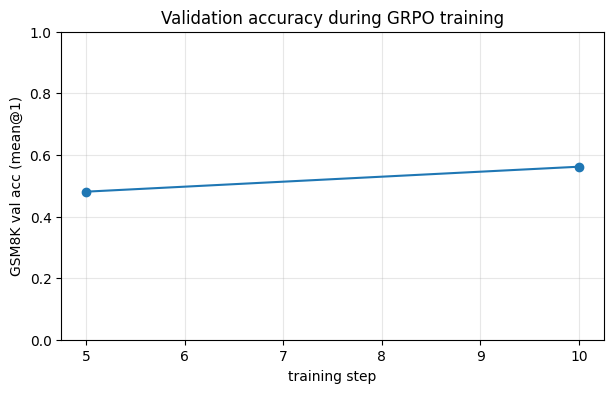

In [45]:
import re
from pathlib import Path
import matplotlib.pyplot as plt

train_dir = Path(Path("/tmp/verl_last_run").read_text().strip())
log_file  = train_dir / "train_log.txt"

step_re = re.compile(r"training/global_step:(\d+)")
acc_re  = re.compile(r"val-core/openai/gsm8k/acc/mean@1:np\.float64\(([0-9.eE+-]+)\)")

steps, accs = [], []
for line in log_file.read_text(errors="ignore").splitlines():
  ms, ma = step_re.search(line), acc_re.search(line)
  if ms and ma:
      steps.append(int(ms.group(1)))
      accs.append(float(ma.group(1)))

print(f"Validation points so far: {len(accs)}")
for s, a in zip(steps, accs):
  print(f"  step {s:>3}: acc = {a:.4f}")

if accs:
  plt.figure(figsize=(7, 4))
  plt.plot(steps, accs, marker="o")
  plt.xlabel("training step")
  plt.ylabel("GSM8K val acc (mean@1)")
  plt.title("Validation accuracy during GRPO training")
  plt.grid(True, alpha=0.3)
  plt.ylim(0, 1)
  plt.show()
else:
  plt.show  # no points yet
  print("(no validation points yet — first one lands at step 5)")

### 如何停止当前训练任务

模型会每 **20 steps** 保存一次 checkpoint，大约需要 **20 分钟**。

本次 workshop 的总训练步数设置为 **40 steps**，因此完整训练大约需要 **40 分钟**。

如果你希望在第一个 checkpoint 保存完成后，直接使用该 checkpoint 进行下面的 inference 部分，可以在第一个 checkpoint 保存后，执行下面的 cell 来停止当前训练任务。

> 当前配置 `save_freq=20`，因此第一个 checkpoint 会保存在 `global_step_20/` 目录下。

In [46]:
%%bash
set -e

train_dir=$(cat /tmp/verl_last_run)
pid=$(cat "${train_dir}/train.pid")

echo "Stopping training: pid=${pid}, run=${train_dir}"

# 1. TERM the launcher (graceful — gives Ray a chance to clean up).
kill -TERM "${pid}" 2>/dev/null && echo "  sent TERM to ${pid}" || echo "  ${pid} already gone"

# 2. Give it a few seconds to exit, then KILL if still alive.
for i in 1 2 3 4 5; do
if [ ! -d "/proc/${pid}" ]; then break; fi
sleep 1
done
if [ -d "/proc/${pid}" ]; then
kill -KILL "${pid}" 2>/dev/null && echo "  sent KILL to ${pid}"
fi

# 3. Sweep up Ray workers and vLLM engine processes verl spawned.
#    These are siblings, not children of the launcher, so kill -- -PID misses them.
pkill -KILL -f "verl.trainer.main_ppo" 2>/dev/null || true
pkill -KILL -f "ray::"                  2>/dev/null || true
pkill -KILL -f "vllm"                   2>/dev/null || true

# 4. Verify nothing is still holding GPU memory.
echo ""
echo "--- remaining verl/ray/vllm processes (should be empty) ---"
pgrep -af "verl.trainer.main_ppo|ray::|vllm" || echo "(none)"

Stopping training: pid=69152, run=/workspace/outputs/verl_grpo_lora_gsm8k/qwen3_4b_lora_vllm_fsdp_20260513.102018
  sent TERM to 69152

--- remaining verl/ray/vllm processes (should be empty) ---
(none)


## Step 8: 使用训练后的 Checkpoint 进行推理

加载训练后的模型，并让它解一道未见过的 GSM8K 风格数学题，观察 GRPO 是否真的改变了模型的输出行为。

**这个代码单元会做三件事：**
1. 找到最新的 `global_step_<N>/` checkpoint.
2. 通过 `verl.model_merger` 将 FSDP 分片和 LoRA adapter 合并成 Hugging Face 格式，并缓存到：`${checkpoint}/actor/merged_hf/`
3. 使用 `transformers` 加载合并后的模型做推理。

**这个步骤需要：** 至少已经保存了一个 checkpoint, 当前 `save_freq=20`，所以第一个 `checkpoint` 会在 step 20 生成

经过 GRPO 训练后，通常可以看到：
- 推理过程更清晰
- 更稳定地输出 #### 格式
- 答案正确率更高

In [47]:
import subprocess
from pathlib import Path
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. Locate the latest checkpoint from the most recent run.
train_dir = Path(Path("/tmp/verl_last_run").read_text().strip())
ckpts = sorted(train_dir.glob("global_step_*"),
             key=lambda p: int(p.name.split("_")[-1]))
assert ckpts, (
  f"No checkpoints in {train_dir}. Set trainer.save_freq > 0 and let "
  f"training run at least that many steps before retrying."
)
latest = ckpts[-1]
actor_dir = latest / "actor"
merged_dir = actor_dir / "merged_hf"
print(f"Latest checkpoint : {latest.name}   (step {latest.name.split('_')[-1]})")
print(f"FSDP shards dir   : {actor_dir}")
print(f"Target HF dir     : {merged_dir}")

# 2. Merge FSDP shards + LoRA adapter -> HF format (skip if already done).
if not (merged_dir / "config.json").exists():
  print("\nMerging FSDP shards + LoRA adapter into HF format...")
  subprocess.run([
      "python3", "-m", "verl.model_merger", "merge",
      "--backend", "fsdp",
      "--local_dir", str(actor_dir),
      "--target_dir", str(merged_dir),
  ], check=True)
  print(f"Merged model written to: {merged_dir}")
else:
  print(f"\nAlready merged at {merged_dir}, skipping merge step.")

# 3. Load the merged model and run a sample prompt.
print("\nLoading merged model on GPU 0...")
tok = AutoTokenizer.from_pretrained(str(merged_dir))
model = AutoModelForCausalLM.from_pretrained(
  str(merged_dir), torch_dtype=torch.bfloat16, device_map="cuda:0"
)
model.eval()

# Held-out problem from /root/data/gsm8k/test.parquet (index 137).
# Gold answer: 29
question = (
  "Rory orders 2 subs for $7.50 each, 2 bags of chips for $1.50 each "
  "and 2 cookies for $1.00 each for delivery. There's a 20% delivery fee "
  "added at check out and she wants to add a $5.00 tip. "
  "What will her delivery order cost? "
  'Let\'s think step by step and output the final answer after "####".'
)

inputs = tok.apply_chat_template(
  [{"role": "user", "content": question}],
  add_generation_prompt=True,
  return_tensors="pt",
).to("cuda:0")

with torch.no_grad():
  out = model.generate(
      inputs,
      max_new_tokens=1024,
      do_sample=False,        # greedy → deterministic, matches GRPO eval
      temperature=0.0,
      pad_token_id=tok.eos_token_id,
  )

response = tok.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
print("\n" + "=" * 70)
print("Question:", question)
print("=" * 70)
print(response)

AssertionError: No checkpoints in /workspace/outputs/verl_grpo_lora_gsm8k/qwen3_4b_lora_vllm_fsdp_20260513.102018. Set trainer.save_freq > 0 and let training run at least that many steps before retrying.